# Multi-Class Image Classification

1. Become one with the data
2. Preprocess the data
3. Create a model
4. Fit the model (overfit it)
5. Evaluate the model
6. Adjust different hyper parameters and import the model
7. Repeat until satisfied

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential as seq
from tensorflow.keras.layers import Dense, MaxPool2D, Conv2D
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from pathlib import Path
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Become one with the data

In [2]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip the file

with zipfile.ZipFile('10_food_classes_all_data.zip') as zipref:
  zipref.extractall()

--2026-05-13 06:12:51--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   296MB/s    in 1.7s    

2026-05-13 06:12:53 (296 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [3]:
# Walkthrough the classes of image data
for dirpath, dirnames, filenames in os.walk('10_food_classes_all_data'):
  print(f'There are {len(dirnames)} directories and {len(filenames)} image in folder : {dirpath}')

There are 2 directories and 0 image in folder : 10_food_classes_all_data
There are 10 directories and 0 image in folder : 10_food_classes_all_data/test
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/steak
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/hamburger
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/ramen
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/sushi
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/chicken_curry
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/fried_rice
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/ice_cream
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/pizza
There are 0 directories and 250 image in folder : 10_food_classes_all_data/test/grilled_salmon
There are 0 directories and 250 image in fol

In [4]:
# Setup the train and test directories
train_dir = '10_food_classes_all_data/train/'
test_dir = '10_food_classes_all_data/test/'

In [5]:
# Get class names
data_dir = Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [6]:
# Visualize images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup the target directory
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  # Read in the image and plot it
  img = mpimg.imread(target_folder + '/' + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  # Show image shape
  print(f'Image shape: {img.shape}')

  return img

['532366.jpg']
Image shape: (512, 287, 3)


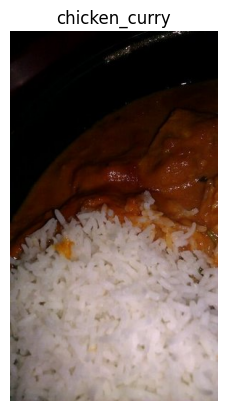

In [7]:
# Visualize the data
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

### 2. Preprocess the data

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale
train_datagen = ImageDataGenerator(rescale=1/255.,)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data from folders
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode='categorical')
test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             batch_size=32,
                                             target_size=(224,224),
                                             class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### 3. Create a model (baseline)

In [9]:
from tensorflow.keras.layers import Activation, Flatten

In [24]:
# Set random seed
tf.random.set_seed(42)

model_1 = seq([
    Conv2D(10,3, input_shape=(224,224,3)),
    Activation('relu'),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax'),
])

# Compile the model
model_1.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=Adam(),
    metrics=['accuracy']
)

In [11]:
history = model_1.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 169ms/step - accuracy: 0.1840 - loss: 2.1972 - val_accuracy: 0.2444 - val_loss: 2.0910
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.3205 - loss: 1.9313 - val_accuracy: 0.3172 - val_loss: 1.9483
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.5336 - loss: 1.4099 - val_accuracy: 0.2976 - val_loss: 2.1419
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.7745 - loss: 0.7016 - val_accuracy: 0.2936 - val_loss: 2.8584
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 141ms/step - accuracy: 0.9344 - loss: 0.2313 - val_accuracy: 0.2552 - val_loss: 4.3374
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - accuracy: 0.9857 - loss: 0.0672 - val_accuracy: 0.2592 - val_loss: 5.2576
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9932 - loss: 0.0354 - val_accuracy: 0.2616 - val_loss: 6.3872
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.9911 - loss: 0

### 5.Evaluate the model

In [12]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('loss')
  plt.xlabel('epochs')
  plt.legend()

  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('accuracy')
  plt.xlabel('epochs')
  plt.legend()

In [13]:
# Evalute on test data
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.2316 - loss: 6.7322


[6.732243061065674, 0.23160000145435333]

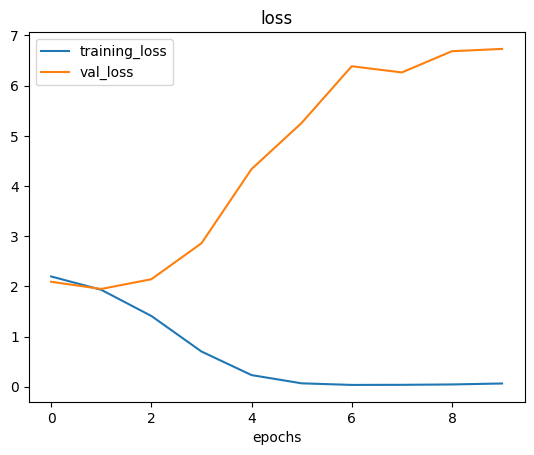

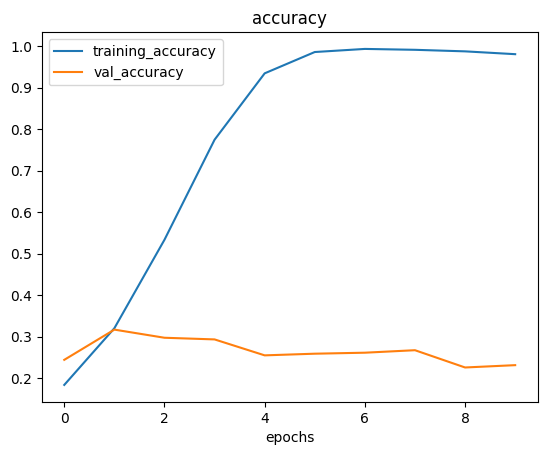

In [14]:
# Check out the model's loss curves on the 10 classes
plot_loss_curves(history)

Loss curves show that the model is overfitting the train set.

### 6. Adjust the model hyperparameters (reduce overfitting)

1. Get more data
2. Regularization
3. Simplify the model
4. Data augmentation
5. Transfer Learning

In [15]:
# Simplify the model
# Remove 2 Conv2D layer

# Set seed
tf.random.set_seed(42)

model_2 = seq([
    Conv2D(10,3,activation='relu',input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

model_2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history_2 = model_2.fit(train_data,
            epochs=5,
            validation_data=test_data,
            steps_per_epoch=len(train_data),
            validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.2296 - loss: 2.1694 - val_accuracy: 0.2732 - val_loss: 2.0067
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.3697 - loss: 1.8214 - val_accuracy: 0.2820 - val_loss: 1.9993
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.5173 - loss: 1.4248 - val_accuracy: 0.2908 - val_loss: 2.1113
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.6945 - loss: 0.9546 - val_accuracy: 0.2756 - val_loss: 2.3751
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 127ms/step - accuracy: 0.8347 - loss: 0.5657 - val_accuracy: 0.2552 - val_loss: 2.8966


In [16]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,402 (3.35 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 585,602 (2.23 MB)

In [17]:
# Evaluate model
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2552 - loss: 2.8966


[2.896634101867676, 0.25519999861717224]

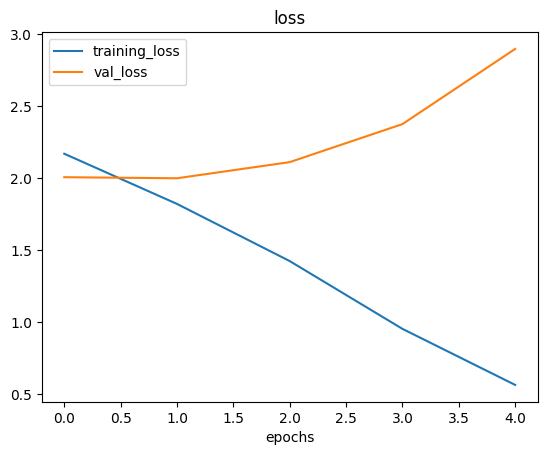

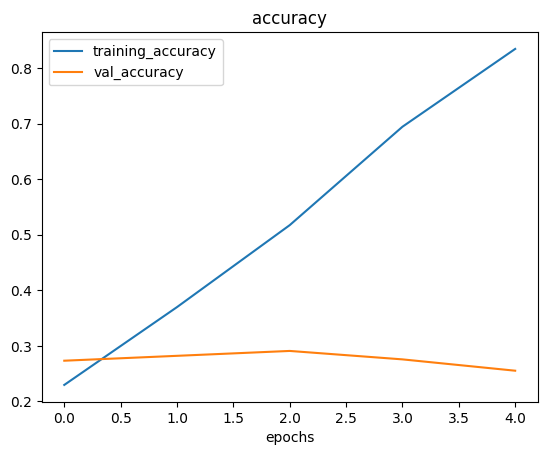

In [18]:
plot_loss_curves(history_2)

### Reduce overfitting using data augmentation

In [26]:
IMG_SIZE = (224, 224)
INPUT_SIZE = (224, 224, 3)

In [27]:
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             zoom_range=0.1,
                                             shear_range=0.2,
                                             width_shift_range=.2,
                                             height_shift_range=0.2,
                                             rotation_range=0.2,
                                             horizontal_flip=True,
                                             vertical_flip=True)


In [28]:
train_data_augmented = train_datagen_augmented.flow_from_directory(directory=train_dir,
                                                                   target_size=IMG_SIZE,
                                                                   class_mode='categorical')

Found 7500 images belonging to 10 classes.


In [29]:
# Create another model for augmented training
model_3 = tf.keras.models.clone_model(model_1)

# Compile the model
model_3.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history_3 = model_3.fit(train_data_augmented,
            epochs=5,
            steps_per_epoch=len(train_data_augmented),
            validation_data=test_data,
            validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 110s 458ms/step - accuracy: 0.1700 - loss: 2.2564 - val_accuracy: 0.2480 - val_loss: 2.0456
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 472ms/step - accuracy: 0.2255 - loss: 2.1223 - val_accuracy: 0.2660 - val_loss: 2.0405
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 123s 522ms/step - accuracy: 0.2455 - loss: 2.0946 - val_accuracy: 0.3064 - val_loss: 1.9883
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 129s 548ms/step - accuracy: 0.2560 - loss: 2.0795 - val_accuracy: 0.2932 - val_loss: 1.9841
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 108s 458ms/step - accuracy: 0.2715 - loss: 2.0599 - val_accuracy: 0.2996 - val_loss: 1.9802


In [30]:
model_3.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.2996 - loss: 1.9802


[1.9802371263504028, 0.2996000051498413]

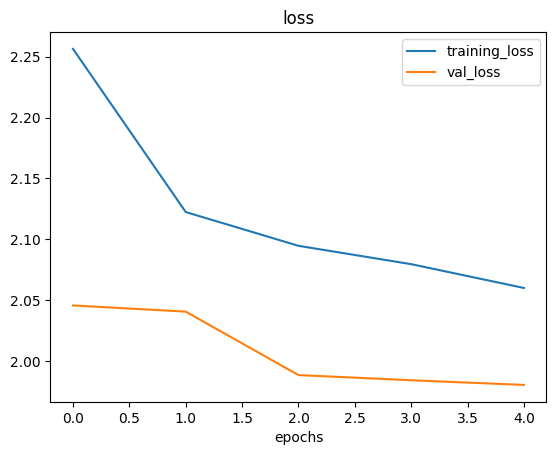

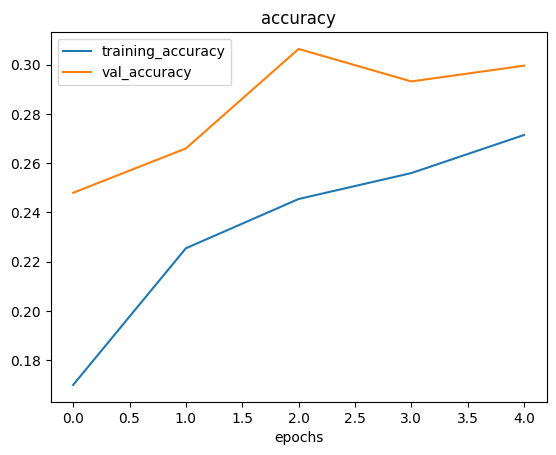

In [31]:
plot_loss_curves(history_3)

### 7. Repeat until satisfied

1. Train for longer
2. Try differnet augmentations
3. Transfer Learning
4. More data

### Making prediction on custom images

In [32]:
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [33]:
# -q is for "quiet"
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
!wget -q https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg

In [37]:
def load_and_prep_image(filename, image_shape=224):
  """
  Reads an image from filename, turns it into a tensor and reshapes it to
  (img_shape, img_shape, color_channels)
  """

  # Read in the image
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor
  img = tf.image.decode_image(img)

  #Resize the image
  img = tf.image.resize(img, size=[image_shape,image_shape])

  # Rescale the image (get all the values between 0 and 1)
  img = img/255.
  return img

In [49]:
# Make prediction using model_3

# Reconfig the funciton to work with multiclass images
def  pred_and_plot(model, filename, class_names=class_names):
  """
  Import an image located at filename, makes a prediction with model
  and plots the image with the predicted class as teh title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  pred = model.predict(tf.expand_dims(img, axis=0))
  pred_class = None

  if len(pred[0]) > 1:
    # Multi class
    pred_class = class_names[tf.argmax(pred[0], axis=0)]
  else:
    # Get teh predicted class
    pred_class = class_names[int(tf.round(pred))]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f'Prediction: {pred_class}')
  plt.axis(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


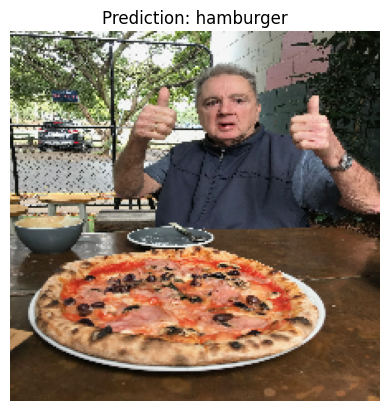

In [50]:
pred_and_plot(model=model_3,
              filename='03-pizza-dad.jpeg',
              class_names=class_names)

### 8. Save and Load the Training model

In [51]:
# Save a model
model_3.save('saved_trained_model.keras')

In [52]:
# Load in the trained model
loaded_model_10 = tf.keras.models.load_model('saved_trained_model.keras')

In [53]:
loaded_model_10.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.2996 - loss: 1.9802


[1.9802367687225342, 0.2996000051498413]

In [55]:
model_3.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.2996 - loss: 1.9802


[1.9802367687225342, 0.2996000051498413]

# Exercises

### E1. Finding ideal learning rate

In [56]:
# Make new model
model_4 = tf.keras.models.clone_model(model_1)

model_4.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [59]:
# Setup lr scheduler
from tensorflow.keras.callbacks import LearningRateScheduler

lr_scheduler = LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

history_4 = model_4.fit(
    train_data_augmented,
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[lr_scheduler],
    epochs=30
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 556ms/step - accuracy: 0.1632 - loss: 2.2303 - val_accuracy: 0.2272 - val_loss: 2.0816 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 150s 637ms/step - accuracy: 0.2507 - loss: 2.1006 - val_accuracy: 0.2676 - val_loss: 1.9929 - learning_rate: 0.0011
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 148s 630ms/step - accuracy: 0.2832 - loss: 2.0333 - val_accuracy: 0.2568 - val_loss: 1.9985 - learning_rate: 0.0013
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 433ms/step - accuracy: 0.2939 - loss: 2.0090 - val_accuracy: 0.3468 - val_loss: 1.8692 - learning_rate: 0.0014
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 430ms/step - accuracy: 0.3005 - loss: 1.9855 - val_accuracy: 0.3784 - val_loss: 1.8102 - learning_rate: 0.0016
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 431ms/step - accuracy: 0.3041 - loss: 1.9754 - val_accuracy: 0.3528 - val_loss: 1.8445 - learning_rate: 0.0018
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 433ms/step - accura

Text(0.5, 1.0, 'Learning Rate vs. Loss Curve')

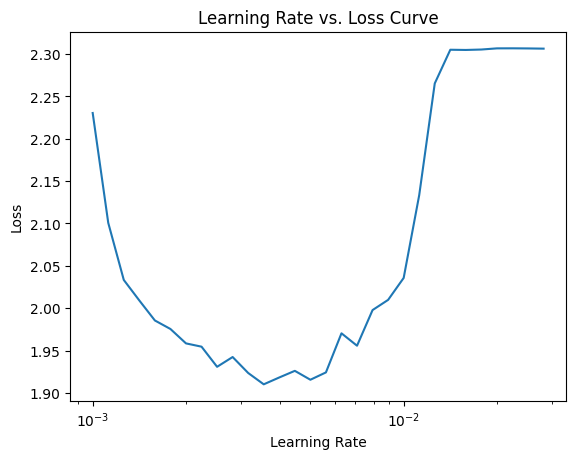

In [61]:
import matplotlib.pyplot as plt

lrs = 1e-3 * 10**(tf.range(30)/20)
plt.semilogx(lrs,history_4.history['loss'])
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('Learning Rate vs. Loss Curve')

In [ ]:
model_5 = tf.keras.models.clone_model(model_1)

model_5.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0015),
    metrics=['accuracy']
)

history_5 = model_5.fit(
    train_data_augmented,
    epochs=5,
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 450ms/step - accuracy: 0.1765 - loss: 2.2187 - val_accuracy: 0.2012 - val_loss: 2.1303
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.2257 - loss: 2.1419

In [ ]:
model_5.evaluate(test_data)

In [ ]:
plot_loss_curves(history_5)